# NOTEBOOK ANN (Dense) : 
#### **Comprendre la capacité + écrire un modèle de plusieurs façons** 

### Objectifs :
* #### Revoir ANN Dense et comprendre "ce qu’il y a dedans" (W, b, activation)
* #### Comprendre la notion de capacité (underfit / bon fit / sur-capacité)
* #### Manipuler learning_rate / epochs / batch_size (intuition)
* #### Découvrir plusieurs manières d’écrire un modèle Keras :
    * #### 1) Sequential
    * #### 2) Functional API
    * #### 3) Fonction "build_model" (hyperparamétrable)

## 0) Imports & Setup

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, accuracy_score

import tensorflow as tf

np.random.seed(42)
tf.random.set_seed(42)

print("TensorFlow:", tf.__version__)

TensorFlow: 2.16.2


In [8]:
# Configuration GPU : activer la croissance dynamique de la mémoire
# Cela évite les erreurs de mémoire GPU
try:
    gpus = tf.config.list_physical_devices('GPU')
    if gpus:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print(f"GPU(s) détecté(s): {len(gpus)} - Croissance mémoire activée")
    else:
        print("Aucun GPU détecté - Utilisation du CPU")
except Exception as e:
    print(f"Configuration GPU: {e}")
    print("Utilisation du CPU par défaut")

# Configuration pour des graphiques de qualité
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Pour la reproductibilité
np.random.seed(42)
tf.random.set_seed(42)

print(f"TensorFlow version: {tf.__version__}")
print(f"Keras version: {tf.keras.__version__}")

GPU(s) détecté(s): 1 - Croissance mémoire activée
TensorFlow version: 2.16.2
Keras version: 3.13.2


## 1) Data : make_moons + split + scaling

In [9]:
# On reste sur make_moons pour garder une continuité pédagogique avec Notebook 1.

X, y = make_moons(n_samples=2000, noise=0.25, random_state=42)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Train:", X_train_scaled.shape, "Test:", X_test_scaled.shape)

Train: (1500, 2) Test: (500, 2)


## 2) Outils : plots (courbes + frontières)

In [10]:
def plot_history(history, title_prefix=""):
    plt.figure()
    plt.plot(history.history["loss"], label="train_loss")
    plt.plot(history.history["val_loss"], label="val_loss")
    plt.title(f"{title_prefix}Loss")
    plt.xlabel("epoch")
    plt.ylabel("loss")
    plt.legend()
    plt.show()

    if "accuracy" in history.history:
        plt.figure()
        plt.plot(history.history["accuracy"], label="train_acc")
        plt.plot(history.history["val_accuracy"], label="val_acc")
        plt.title(f"{title_prefix}Accuracy")
        plt.xlabel("epoch")
        plt.ylabel("accuracy")
        plt.legend()
        plt.show()

In [11]:
def plot_decision_boundary_keras(model, scaler, X, y, title):
    x_min, x_max = X[:, 0].min() - 0.8, X[:, 0].max() + 0.8
    y_min, y_max = X[:, 1].min() - 0.8, X[:, 1].max() + 0.8

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 300),
        np.linspace(y_min, y_max, 300)
    )
    grid = np.c_[xx.ravel(), yy.ravel()]
    grid_scaled = scaler.transform(grid)

    proba = model.predict(grid_scaled, verbose=0).ravel()
    Z = (proba >= 0.5).astype(int).reshape(xx.shape)

    plt.figure()
    plt.contourf(xx, yy, Z, alpha=0.25)
    plt.scatter(X[:, 0], X[:, 1], c=y)
    plt.title(title)
    plt.xlabel("x1")
    plt.ylabel("x2")
    plt.show()

In [12]:
def evaluate_binary_keras(model, X_test_scaled, y_test, title=""):
    proba = model.predict(X_test_scaled, verbose=0).ravel()
    y_pred = (proba >= 0.5).astype(int)
    acc = accuracy_score(y_test, y_pred)

    print(f"\n=== {title} ===")
    print("Accuracy test:", round(acc, 4))
    print(classification_report(y_test, y_pred))
    return acc

## 3) Rappel : un neurone Dense = Wx + b puis activation(...)

#### **Dense calcule : z = X @ W + b**

#### **Puis on applique une activation (ex: ReLU) : a = relu(z)**

* #### Ici on va :
    * #### entraîner un petit modèle

    * #### récupérer W et b
    
    * #### regarder leurs formes


### 3.1) Modèle ANN simple (Sequential)

In [13]:
model_seq = tf.keras.Sequential([
    tf.keras.layers.Dense(8, activation="relu", input_shape=(2,)),
    tf.keras.layers.Dense(1, activation="sigmoid")
])

model_seq.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model_seq.summary()

/Users/jika/Desktop/ENSEIGMEMENT/Machine Learing/ALYRA - IA/ai-dev-teaching-hub/.venv/lib/python3.11/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2026-03-05 11:29:26.244453: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M4
2026-03-05 11:29:26.244485: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 24.00 GB
2026-03-05 11:29:26.244492: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 8.88 GB
2026-03-05 11:29:26.244512: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-03-05 11:29:26.244525: I tensorflow/core/common_runti

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 8)              │            24 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 33 (132.00 B)

 Trainable params: 33 (132.00 B)

 Non-trainable params: 0 (0.00 B)

In [14]:
print("Nombre total de paramètres :", model_seq.count_params())

Nombre total de paramètres : 33


#### ANATOMIE DU RÉSEAU

**Notre modèle est composé de 3 parties logiques :**  

1) Input Layer
    
    - Ce n’est pas une vraie couche avec des poids.
    
    - Elle définit simplement la dimension des données d’entrée.
    
    - Ici : shape=(2,) -> chaque observation a 2 variables (x1, x2).

2) Hidden Layer (Dense 8, activation="relu")
    
    - 8 neurones
    
    - Chaque neurone calcule : z = w1*x1 + w2*x2 + b
    
    - Puis applique une activation : relu(z)
    
    **Analogie :**  
    Chaque neurone est comme un "petit expert" qui regarde les 2 variables et produit une nouvelle représentation.**

3) Output Layer (Dense 1, activation="sigmoid")
    
    - 1 neurone
    
    - Combine les 8 sorties intermédiaires
    
    - Sigmoid transforme le résultat en probabilité (entre 0 et 1)


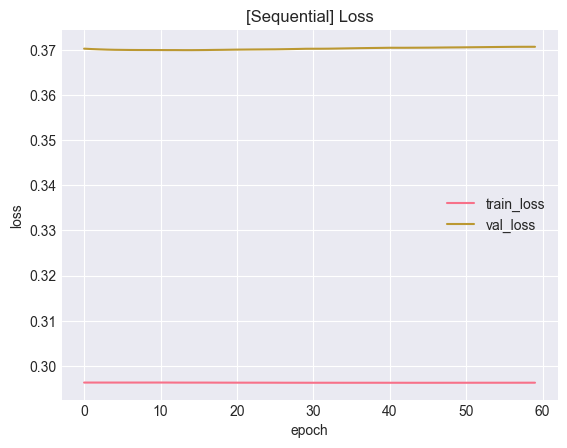

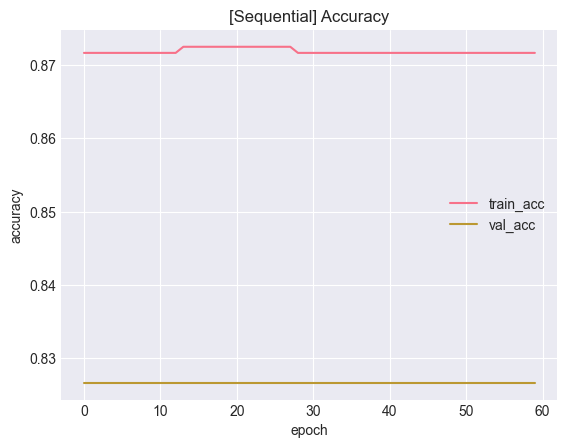


=== Sequential - ANN(8) ===
Accuracy test: 0.882
              precision    recall  f1-score   support

           0       0.88      0.89      0.88       250
           1       0.89      0.88      0.88       250

    accuracy                           0.88       500
   macro avg       0.88      0.88      0.88       500
weighted avg       0.88      0.88      0.88       500



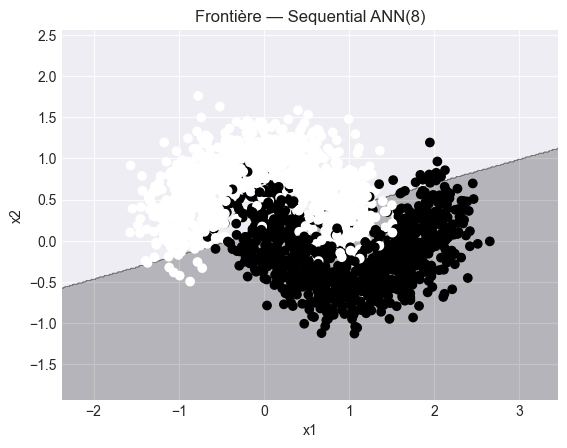

In [16]:
history_seq = model_seq.fit(
    X_train_scaled, y_train,
    epochs=60,
    batch_size=32,
    validation_split=0.2,
    verbose=0 # pour afficher ou non les epochs d'apprentissage
)

plot_history(history_seq, title_prefix="[Sequential] ")
evaluate_binary_keras(model_seq, X_test_scaled, y_test, title="Sequential - ANN(8)")
plot_decision_boundary_keras(model_seq, scaler, X, y, title="Frontière — Sequential ANN(8)")

### 3.2) Regarder les poids d’une couche Dense

##### **layer 0 = Dense(8).**
##### **Ses poids W ont forme (n_features, n_neurons) = (2, 8) et son biais b a forme (8,)**


In [18]:
dense0 = model_seq.layers[0]
W0, b0 = dense0.get_weights()

print("\nCouche 0 (Dense 8 ReLU) :")
print(" - W shape:", W0.shape)
print(" - b shape:", b0.shape)

print("\nExtrait W (5 valeurs) :", W0.ravel()[:5])
print("Extrait b (5 valeurs) :", b0.ravel()[:5])

# Petite démo : si X a shape (N, 2), alors z = X @ W + b -> shape (N, 8)
X_demo = X_train_scaled[:3]  # 3 points
z_demo = X_demo @ W0 + b0
print("\nDémo : z_demo shape (attendu (3,8)) ->", z_demo.shape)


Couche 0 (Dense 8 ReLU) :
 - W shape: (2, 8)
 - b shape: (8,)

Extrait W (5 valeurs) : [ 0.01226317  1.2182128  -1.752891   -1.0847198   0.1177542 ]
Extrait b (5 valeurs) : [-0.08783584  0.7075853  -1.0221633  -0.64653176  0.6553388 ]

Démo : z_demo shape (attendu (3,8)) -> (3, 8)


#### INTERPRÉTATION DES POIDS ET BIAIS

W shape = (2, 8)
-> 2 features d’entrée
-> 8 neurones
Donc chaque neurone possède 2 poids.

b shape = (8,)
-> 1 biais par neurone

Formule d’un neurone :
z = w1*x1 + w2*x2 + b
a = activation(z)

#### IMPORTANT :
Sans activation, plusieurs couches Dense seraient équivalentes à une simple transformation linéaire.  
C’est l’activation (ReLU ici) qui permet la non-linéarité.

In [19]:
print("Exemple : sortie avant activation (z) pour 1 point :")
print(z_demo[0])

Exemple : sortie avant activation (z) pour 1 point :
[-0.09499948  1.1292335  -1.49791324 -0.98506857  0.34233251 -0.84461938
  1.02661937  1.31164597]


## 4) Capacité du modèle : underfit vs bon fit vs sur-capacité

#### On compare plusieurs architectures :
* #### très petit réseau (2 neurones) : risque d'underfitting
* #### réseau moyen (8 neurones) : souvent bon compromis
* #### réseau plus large/profond (64 puis 64) : plus de capacité, plus de risque d’overfitting



Entraînement: Petit (2) | hidden_units: (2,) | lr: 0.001


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 2)              │             6 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │             3 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9 (36.00 B)

 Trainable params: 9 (36.00 B)

 Non-trainable params: 0 (0.00 B)

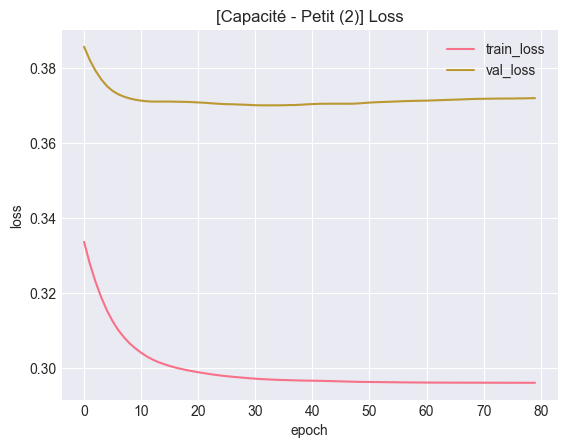

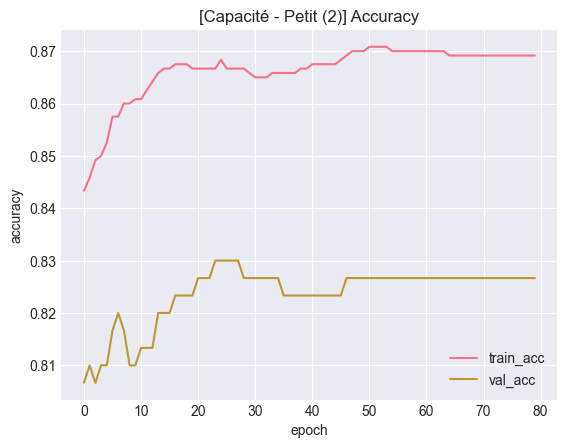


=== Capacité - Petit (2) ===
Accuracy test: 0.886
              precision    recall  f1-score   support

           0       0.88      0.89      0.89       250
           1       0.89      0.88      0.89       250

    accuracy                           0.89       500
   macro avg       0.89      0.89      0.89       500
weighted avg       0.89      0.89      0.89       500



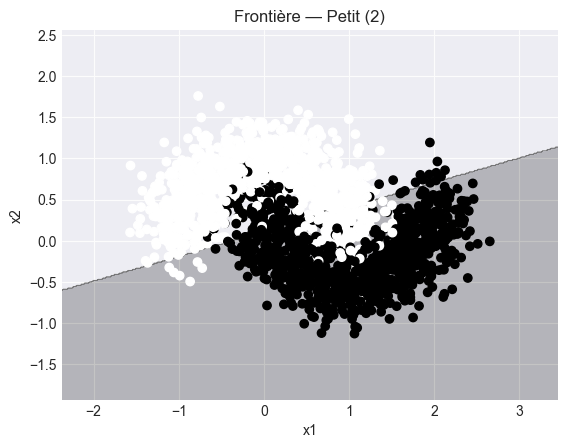


Entraînement: Moyen (8) | hidden_units: (8,) | lr: 0.001


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 8)              │            24 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 33 (132.00 B)

 Trainable params: 33 (132.00 B)

 Non-trainable params: 0 (0.00 B)

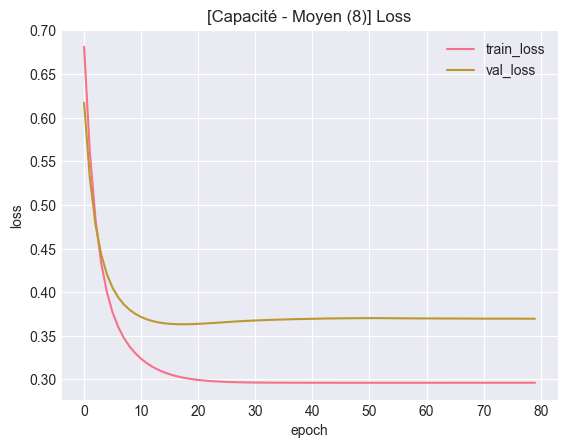

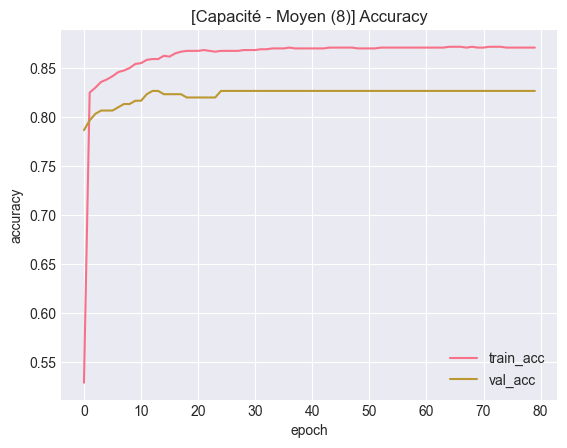


=== Capacité - Moyen (8) ===
Accuracy test: 0.88
              precision    recall  f1-score   support

           0       0.87      0.89      0.88       250
           1       0.89      0.87      0.88       250

    accuracy                           0.88       500
   macro avg       0.88      0.88      0.88       500
weighted avg       0.88      0.88      0.88       500



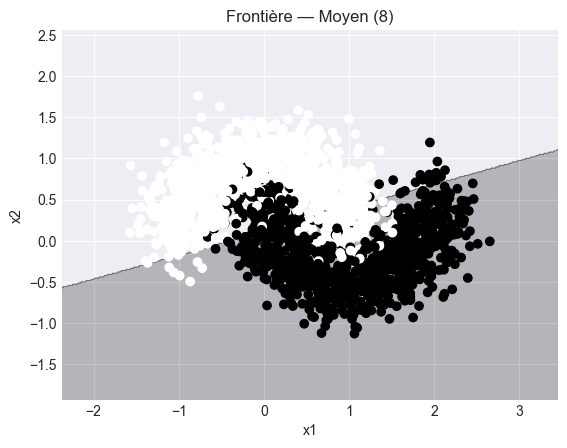


Entraînement: Large (64,64) | hidden_units: (64, 64) | lr: 0.001


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 64)             │           192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,417 (17.25 KB)

 Trainable params: 4,417 (17.25 KB)

 Non-trainable params: 0 (0.00 B)

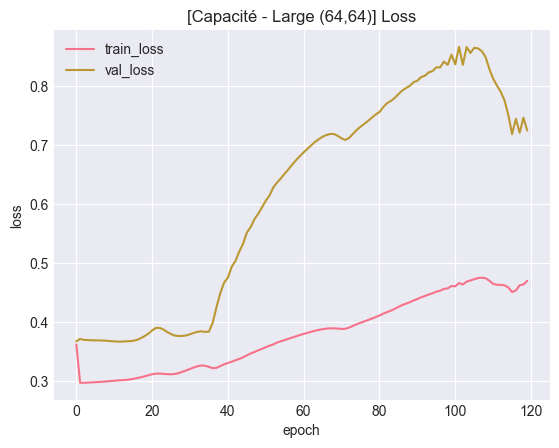

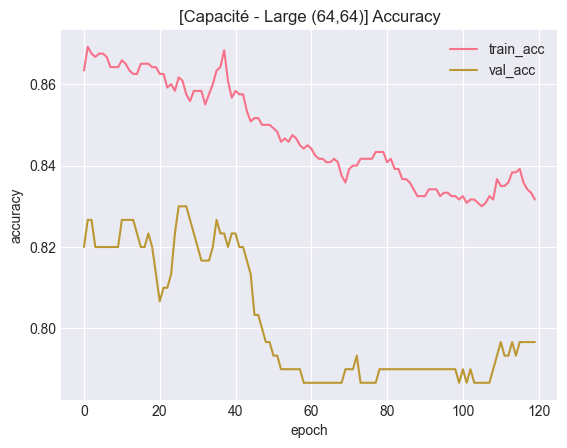


=== Capacité - Large (64,64) ===
Accuracy test: 0.842
              precision    recall  f1-score   support

           0       0.90      0.77      0.83       250
           1       0.80      0.92      0.85       250

    accuracy                           0.84       500
   macro avg       0.85      0.84      0.84       500
weighted avg       0.85      0.84      0.84       500



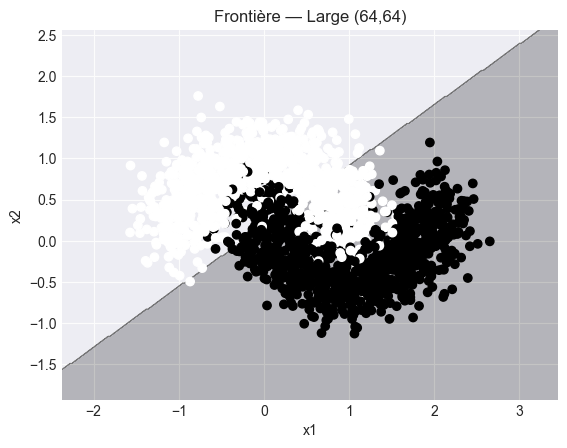

In [20]:
def build_sequential_model(hidden_units=(8,), learning_rate=1e-3):
    layers = [tf.keras.layers.Input(shape=(2,))]
    for u in hidden_units:
        layers.append(tf.keras.layers.Dense(u, activation="relu"))
    layers.append(tf.keras.layers.Dense(1, activation="sigmoid"))

    model = tf.keras.Sequential(layers)

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )
    return model


configs = [
    {"name": "Petit (2)", "hidden_units": (2,), "epochs": 80, "lr": 1e-3},
    {"name": "Moyen (8)", "hidden_units": (8,), "epochs": 80, "lr": 1e-3},
    {"name": "Large (64,64)", "hidden_units": (64, 64), "epochs": 120, "lr": 1e-3},
]

trained_models = {}

for cfg in configs:
    print("\n" + "="*60)
    print("Entraînement:", cfg["name"], "| hidden_units:", cfg["hidden_units"], "| lr:", cfg["lr"])
    model = build_sequential_model(hidden_units=cfg["hidden_units"], learning_rate=cfg["lr"])
    model.summary()

    history = model.fit(
        X_train_scaled, y_train,
        epochs=cfg["epochs"],
        batch_size=32,
        validation_split=0.2,
        verbose=0
    )
    plot_history(history, title_prefix=f"[Capacité - {cfg['name']}] ")
    evaluate_binary_keras(model, X_test_scaled, y_test, title=f"Capacité - {cfg['name']}")
    plot_decision_boundary_keras(model, scaler, X, y, title=f"Frontière — {cfg['name']}")

    trained_models[cfg["name"]] = (model, history)


## 5) Jouer avec le learning rate : intuition

> On illustre :
> 
> - LR trop grand => instable / n’apprend pas bien
>
> - LR trop petit => apprend lentement


Expériences Learning Rate


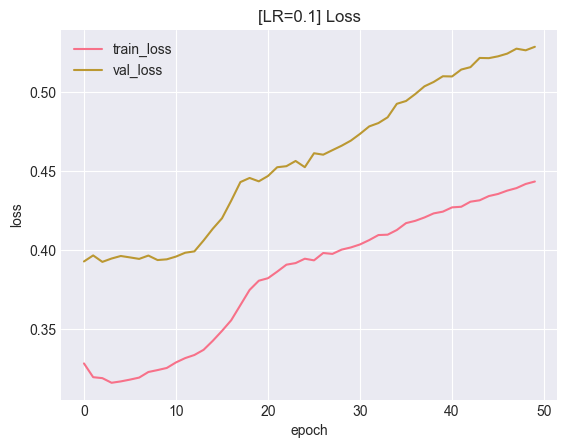

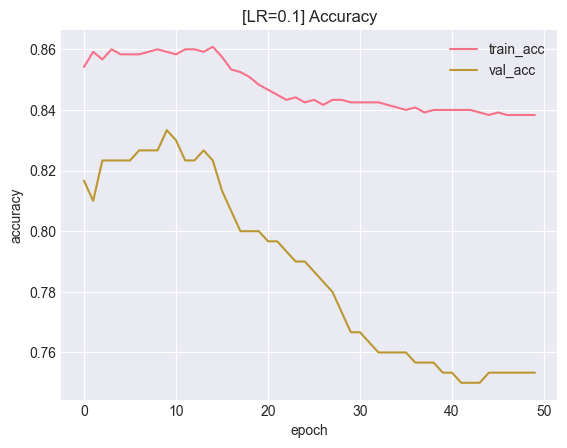


=== LR trop grand (0.1) - ANN(8) ===
Accuracy test: 0.83
              precision    recall  f1-score   support

           0       0.79      0.90      0.84       250
           1       0.88      0.76      0.82       250

    accuracy                           0.83       500
   macro avg       0.84      0.83      0.83       500
weighted avg       0.84      0.83      0.83       500



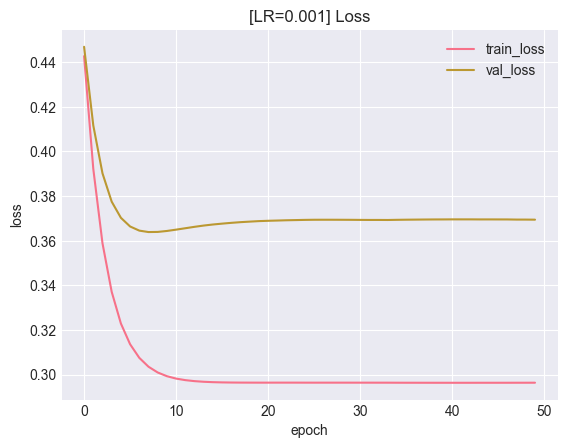

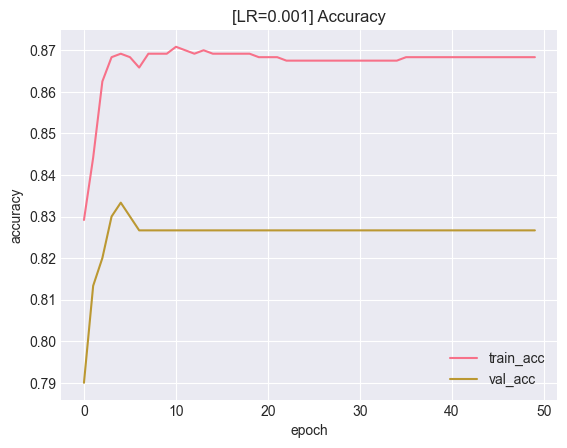


=== LR standard (0.001) - ANN(8) ===
Accuracy test: 0.878
              precision    recall  f1-score   support

           0       0.87      0.89      0.88       250
           1       0.89      0.86      0.88       250

    accuracy                           0.88       500
   macro avg       0.88      0.88      0.88       500
weighted avg       0.88      0.88      0.88       500



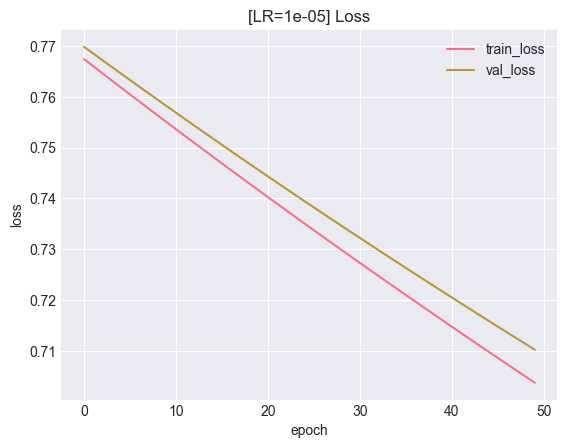

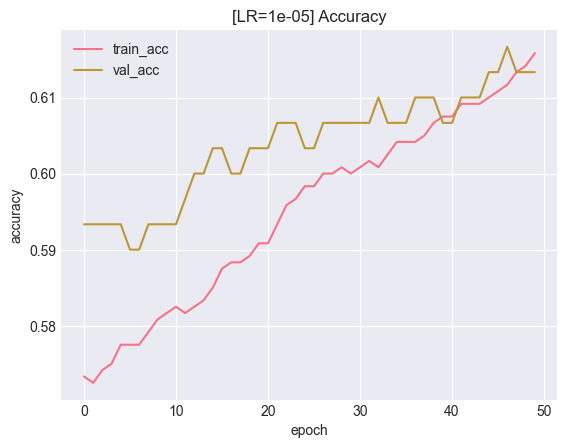


=== LR trop petit (0.00001) - ANN(8) ===
Accuracy test: 0.602
              precision    recall  f1-score   support

           0       0.60      0.60      0.60       250
           1       0.60      0.60      0.60       250

    accuracy                           0.60       500
   macro avg       0.60      0.60      0.60       500
weighted avg       0.60      0.60      0.60       500



In [21]:
def run_lr_experiment(lr, epochs=60, title=""):
    model = build_sequential_model(hidden_units=(8,), learning_rate=lr)
    history = model.fit(
        X_train_scaled, y_train,
        epochs=epochs,
        batch_size=32,
        validation_split=0.2,
        verbose=0
    )
    plot_history(history, title_prefix=f"[LR={lr}] ")
    evaluate_binary_keras(model, X_test_scaled, y_test, title=title)
    return model, history

print("\n" + "="*60)
print("Expériences Learning Rate")

_ = run_lr_experiment(lr=1e-1, epochs=50, title="LR trop grand (0.1) - ANN(8)")
_ = run_lr_experiment(lr=1e-3, epochs=50, title="LR standard (0.001) - ANN(8)")
_ = run_lr_experiment(lr=1e-5, epochs=50, title="LR trop petit (0.00001) - ANN(8)")

## 6) Plusieurs façons d’écrire un modèle Keras

#### On entraîne 3 modèles "équivalents" (même architecture) mais écrits différemment :
* #### A) Sequential
* #### B) Functional API
* #### C) Fonction build_model(...) (hyperparamétrable)

> #### Objectif : 
> **Comprendre que "le modèle" = architecture + compile + fit.**  
>
> **L'écriture peut varier selon le besoin (simplicité vs flexibilité).**


### 6A) Sequential (déjà vu) — on refait en compact


=== A) Sequential ANN(8) ===
Accuracy test: 0.884
              precision    recall  f1-score   support

           0       0.88      0.89      0.88       250
           1       0.89      0.88      0.88       250

    accuracy                           0.88       500
   macro avg       0.88      0.88      0.88       500
weighted avg       0.88      0.88      0.88       500



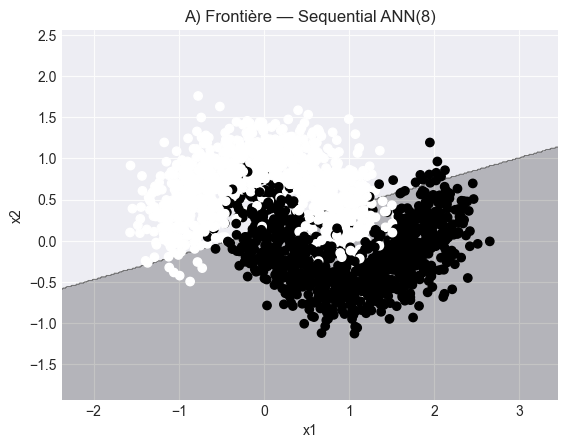

In [22]:
model_A = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(2,)),
    tf.keras.layers.Dense(8, activation="relu"),
    tf.keras.layers.Dense(1, activation="sigmoid")
])

model_A.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

history_A = model_A.fit(
    X_train_scaled, y_train,
    epochs=60,
    batch_size=32,
    validation_split=0.2,
    verbose=0
)

evaluate_binary_keras(model_A, X_test_scaled, y_test, title="A) Sequential ANN(8)")
plot_decision_boundary_keras(model_A, scaler, X, y, title="A) Frontière — Sequential ANN(8)")


### 6B) Functional API

**Idée : construire un graphe de calcul explicite.**  

**Très utile quand :**  

* plusieurs entrées / sorties

* branches, connexions résiduelles, etc.


Model: "functional_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_8 (InputLayer)      │ (None, 2)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 8)              │            24 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 33 (132.00 B)

 Trainable params: 33 (132.00 B)

 Non-trainable params: 0 (0.00 B)


=== B) Functional API ANN(8) ===
Accuracy test: 0.884
              precision    recall  f1-score   support

           0       0.88      0.89      0.88       250
           1       0.89      0.88      0.88       250

    accuracy                           0.88       500
   macro avg       0.88      0.88      0.88       500
weighted avg       0.88      0.88      0.88       500



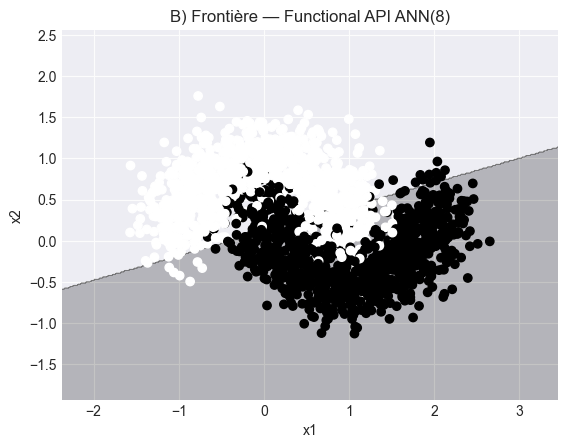

In [23]:
inputs = tf.keras.Input(shape=(2,))
x = tf.keras.layers.Dense(8, activation="relu")(inputs)
outputs = tf.keras.layers.Dense(1, activation="sigmoid")(x)

model_B = tf.keras.Model(inputs=inputs, outputs=outputs)
model_B.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

model_B.summary()

history_B = model_B.fit(
    X_train_scaled, y_train,
    epochs=60,
    batch_size=32,
    validation_split=0.2,
    verbose=0
)

evaluate_binary_keras(model_B, X_test_scaled, y_test, title="B) Functional API ANN(8)")
plot_decision_boundary_keras(model_B, scaler, X, y, title="B) Frontière — Functional API ANN(8)")

### 6C) Fonction build_model (hyperparamétrable)

> **Très utile en projet / expérimentation : on peut tester plusieurs architectures facilement.**



=== C) build_model(...) ANN(8) ===
Accuracy test: 0.884
              precision    recall  f1-score   support

           0       0.88      0.89      0.88       250
           1       0.89      0.88      0.88       250

    accuracy                           0.88       500
   macro avg       0.88      0.88      0.88       500
weighted avg       0.88      0.88      0.88       500



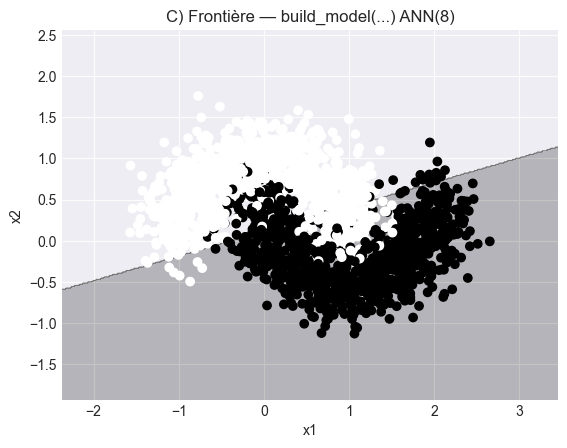

In [24]:
def build_model_dense(n_neurons=8, learning_rate=1e-3):
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(2,)),
        tf.keras.layers.Dense(n_neurons, activation="relu"),
        tf.keras.layers.Dense(1, activation="sigmoid")
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )
    return model

model_C = build_model_dense(n_neurons=8, learning_rate=1e-3)
history_C = model_C.fit(
    X_train_scaled, y_train,
    epochs=60,
    batch_size=32,
    validation_split=0.2,
    verbose=0
)

evaluate_binary_keras(model_C, X_test_scaled, y_test, title="C) build_model(...) ANN(8)")
plot_decision_boundary_keras(model_C, scaler, X, y, title="C) Frontière — build_model(...) ANN(8)")

## 7) Visualisation d'un modèle avec outil externe de viz' (Netron)

In [28]:
model_seq.save("models/ann_dense_model.keras")

print("Modèle sauvegardé sous models/ann_dense_model.keras")

Modèle sauvegardé sous models/ann_dense_model.keras



## RÉSUMÉ STRUCTUREL

#### Un réseau dense = empilement de transformations :

Input (2 variables).  
   ↓  
Dense (8 neurones) -> crée 8 nouvelles représentations.  
   ↓  
Activation (ReLU) -> introduit la non-linéarité.  
   ↓  
Dense (1 neurone).  
   ↓  
Sigmoid -> probabilité finale. 

#### Idée clé :
**Le réseau apprend progressivement des représentations intermédiaires de plus en plus adaptées au problème.**

Ce n’est pas magique.  
Ce sont des matrices optimisées par descente de gradient.

## 8) Conclusion / Messages clés

* #### Dense = Wx + b, puis activation(...) -> ce n’est "que" de l’algèbre linéaire + non-linéarité.

* #### Capacité :
    * #### trop petit => underfitting
    * #### trop grand => risque d’overfitting (on le voit souvent via val_loss qui remonte)

* #### Learning rate :
    * #### trop grand => instable
    * #### trop petit => lent

* #### Keras propose plusieurs manières d’écrire le même modèle :
    #### Sequential (simple), Functional (flexible), build_model (expérimentation).

## Mini questions (pour valider vos compréhensions) :

* #### 1) Dans une Dense(8) avec input_shape=(2,), combien de poids (sans compter les biais) ?
    il y a 16 poids (2 features x 8 neurones).  
  
* #### 2) Pourquoi val_loss peut remonter alors que train_loss baisse ?
    val_loss qui remonte alors que train_loss baisse est souvent un signe d'overfitting.  
    Cela signifie que le modèle s'adapte de plus en plus aux données d'entraînement (train_loss baisse), mais perd en capacité de généralisation sur les données de validation (val_loss remonte). C'est un indicateur que le modèle commence à mémoriser les données d'entraînement plutôt que d'apprendre des patterns généraux.  
  
* #### 3) Quel est l’intérêt de la Functional API ?
    L'intérêt de la Functional API est qu'elle permet de construire des modèles plus complexes et flexibles que le modèle Sequential.   
    Avec la Functional API, on peut créer des architectures avec plusieurs entrées et sorties, des connexions non linéaires entre les couches (comme les connexions résiduelles), et des branches dans le réseau. Cela offre une grande liberté pour concevoir des modèles adaptés à des problèmes spécifiques qui ne peuvent pas être facilement exprimés avec un modèle Sequential.
  
* #### 4) Pourquoi le scaling des inputs aide souvent l’entraînement ?
    Le scaling des inputs aide souvent l'entraînement car il permet d'avoir des données d'entrée dans une plage de valeurs similaire, ce qui facilite la convergence du modèle.  
    Lorsque les données d'entrée ont des échelles très différentes, le modèle peut avoir du mal à apprendre efficacement, car les poids associés à des features avec des valeurs plus grandes peuvent dominer l'apprentissage, tandis que les features avec des valeurs plus petites peuvent être négligées.  
    Le scaling (comme la normalisation ou la standardisation) permet d'atténuer ce problème en mettant toutes les features sur une échelle comparable, ce qui peut améliorer la stabilité et la vitesse de convergence du modèle.